# Causal Attention

1. Also known as "Masked Attention". This is special form of Attention

2. It restricts the model to only consider previous and current inputs in a sequence when processing any given token

3. This is contrast to self attention mechansim which allows access to the entire input sequence at once

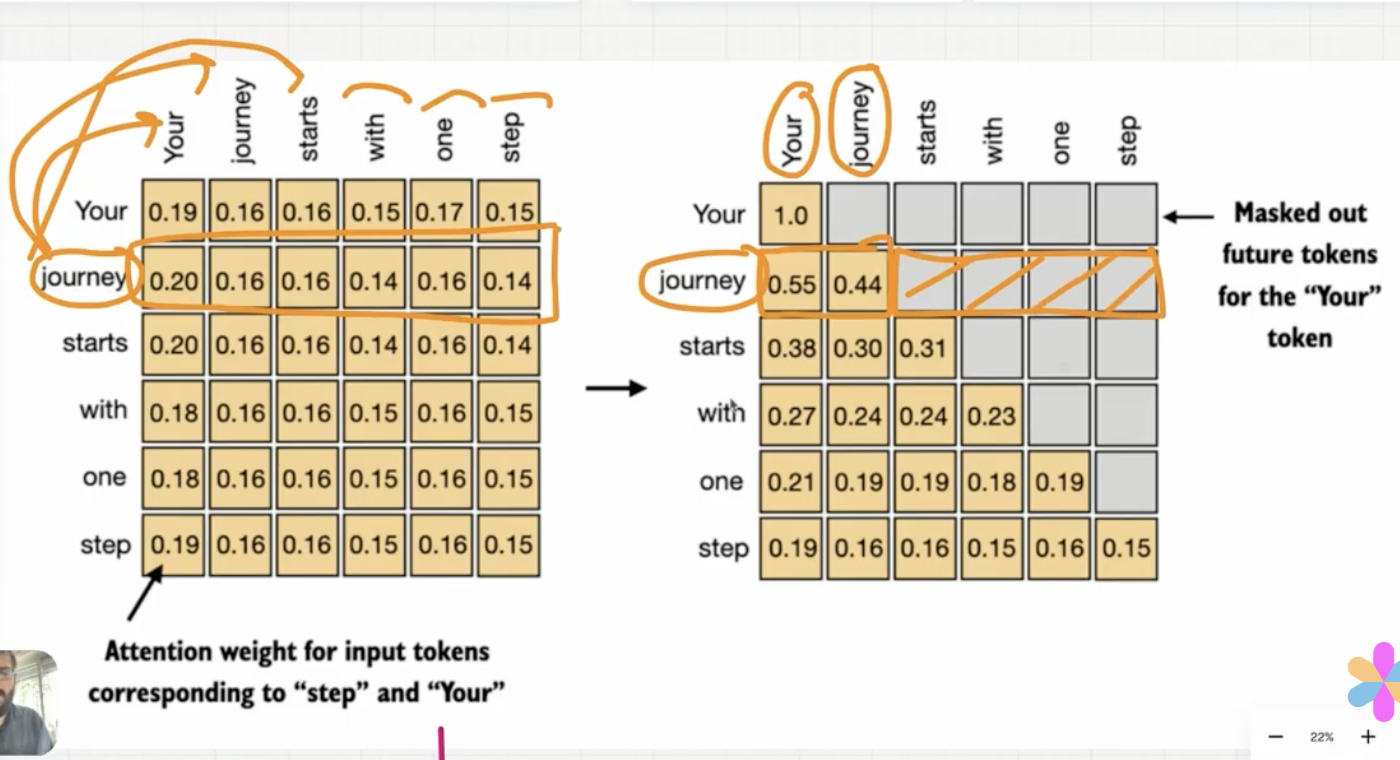

We mask out the attention weights above the diagonal, and we normalize the non masked attention weights, such that the attention weights sum upto 1 in each row

In [1]:
import torch

inputs = torch.tensor(
    [[0.43, 0.15, 0.89],  # Your      (x^1)
     [0.55, 0.87, 0.66],  # journey   (x^2)
     [0.57, 0.85, 0.64],  # starts    (x^3)
     [0.22, 0.58, 0.33],  # with      (x^4)
     [0.77, 0.25, 0.10],  # one       (x^5)
     [0.05, 0.80, 0.55]]  # step      (x^6)
)

In [2]:
import torch
import torch.nn as nn

class CausalAttention_v1(nn.Module):
    
    def __init__(self,d_in,d_out,qkv_bias=False):
        super().__init__()
        self.W_query = nn.Linear(d_in,d_out,bias = qkv_bias)
        self.W_key = nn.Linear(d_in,d_out,bias = qkv_bias)
        self.W_value = nn.Linear(d_in,d_out,bias = qkv_bias)
        
        
    def forward(self,x):
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)
        
        attn_scores = queries @ keys.T

        ## Maksing
        context_length = attn_scores.shape[0]
        mask = torch.triu(torch.ones(context_length,context_length),diagonal=1)
        masked = attn_scores.masked_fill(mask.bool(),-torch.inf)
        

        attn_weights = torch.softmax(masked/keys.shape[-1]**0.5, dim =-1)
        
        context_vec = attn_weights @ values
        return context_vec

In [8]:
torch.manual_seed(123)
d_in = inputs.shape[1]
d_out = 2 ## lets chose this
ca_v1 = CausalAttention_v1(d_in,d_out)
print(ca_v1(inputs))

tensor([[-0.4519,  0.2216],
        [-0.5874,  0.0058],
        [-0.6300, -0.0632],
        [-0.5675, -0.0843],
        [-0.5526, -0.0981],
        [-0.5299, -0.1081]], grad_fn=<MmBackward0>)


# Causal Attention with Dropout

What is Dropout??

- Dropout is a deep learning technique where randomly selected hidden layer units are ignored during training

- This prevents overfitting and improves generalization performance

1. During training of neural networks, some neurons becomes lazy and they do not do any work thinking other neurons are doing most of the work. 

2. To prevent this if we randomly switches off active neuron, then this lazy neuron is forced to do the work. 

3. This ensures all of the neurons do active work.

Different ways to apply dropout - 

1. After calculating attention scores (More common way)

2. After applying attention weights to value vectors

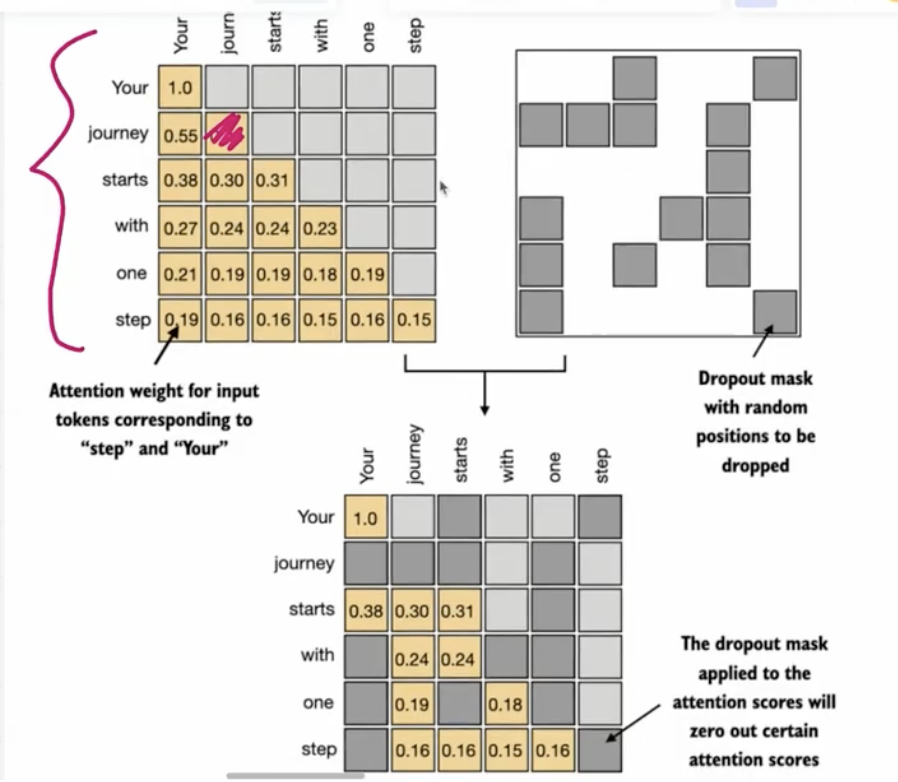

In [6]:
## Example

example = torch.ones(6,6)
print(example)
print("\n")

torch.manual_seed(123)
dropout = torch.nn.Dropout(0.5)
example = torch.ones(6,6)
print(dropout(example))

tensor([[1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.]])


tensor([[2., 2., 0., 2., 2., 0.],
        [0., 0., 0., 2., 0., 2.],
        [2., 2., 2., 2., 0., 2.],
        [0., 2., 2., 0., 0., 2.],
        [0., 2., 0., 2., 0., 2.],
        [0., 2., 2., 2., 2., 0.]])


Note - 

1. As you see in above, drop application is probabilistic

2. To compensate for the reduction in active elements, the values of the remaining elements in the matrix are scaled up by a factor of 1/(1-0.5) = 2 - that is 1/(1-p)

In [12]:
import torch
import torch.nn as nn

class CausalAttention_v2(nn.Module):
    
    def __init__(self,d_in,d_out,context_length,dropout,qkv_bias=False):
        super().__init__()
        self.W_query = nn.Linear(d_in,d_out,bias = qkv_bias)
        self.W_key = nn.Linear(d_in,d_out,bias = qkv_bias)
        self.W_value = nn.Linear(d_in,d_out,bias = qkv_bias)

        self.dropout = nn.Dropout(dropout)
        self.register_buffer('mask',torch.triu(torch.ones(context_length,context_length),diagonal=1))
        
        
    def forward(self,x):
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)
        
        attn_scores = queries @ keys.T

        ## Masking
        context_length = attn_scores.shape[0]
        mask = torch.triu(torch.ones(context_length,context_length),diagonal=1)
        masked = attn_scores.masked_fill(mask.bool(),-torch.inf)

        attn_weights = torch.softmax(masked/keys.shape[-1]**0.5, dim =-1)

        ## drop out
        attn_weights= self.dropout(attn_weights)

        
        context_vec = attn_weights @ values
        return context_vec

In [19]:
torch.manual_seed(123)
ca_v2 = CausalAttention_v2(d_in,d_out,context_length=d_in,dropout=0.5)
print(ca_v2(inputs))

tensor([[-0.9038,  0.4432],
        [-0.4368,  0.2142],
        [-0.4849, -0.1341],
        [-0.5834,  0.0081],
        [-0.6219, -0.0526],
        [-0.1417, -0.0505]], grad_fn=<MmBackward0>)
